In [2]:
import pandas as pd
from sklearn.preprocessing import scale
from sklearn.impute import SimpleImputer

In [3]:
#Load Dataset
data = pd.read_csv("full_random_pig_dataset_5000.csv")

#categorical to numerical
encoded_data = pd.get_dummies(data, drop_first=True)

#Nan values
imputer = SimpleImputer(strategy='mean')
scaled_data = scale(encoded_data)
scaled_data_clean = imputer.fit_transform(scaled_data)
print(scaled_data)

[[-1.56272168 -1.36961012 -1.27709325 ... -0.02450225 -0.020004
  -0.020004  ]
 [ 1.52784047  0.76671746  1.66333537 ... -0.02450225 -0.020004
  -0.020004  ]
 [ 1.66832057  0.06628219 -1.36467059 ... -0.02450225 -0.020004
  -0.020004  ]
 ...
 [-1.70320178  0.38147806  1.02084319 ... -0.02450225 -0.020004
  -0.020004  ]
 [-1.49248163 -1.26454483 -1.71187987 ... -0.02450225 -0.020004
  -0.020004  ]
 [-1.14128139 -0.94934895 -0.80200555 ... -0.02450225 -0.020004
  -0.020004  ]]


In [4]:
#Define KMeans Clustering Method
from sklearn.cluster import KMeans

k = 10 #number of clusters
kmeans_cluster = KMeans(init = 'random', n_clusters= k, n_init = 10, random_state = 0)

In [5]:
#Model Evaluation
from time import time
from sklearn import metrics

def bench_k_means(estimator, name, data):
    initial_time = time()
    estimator.fit(data)


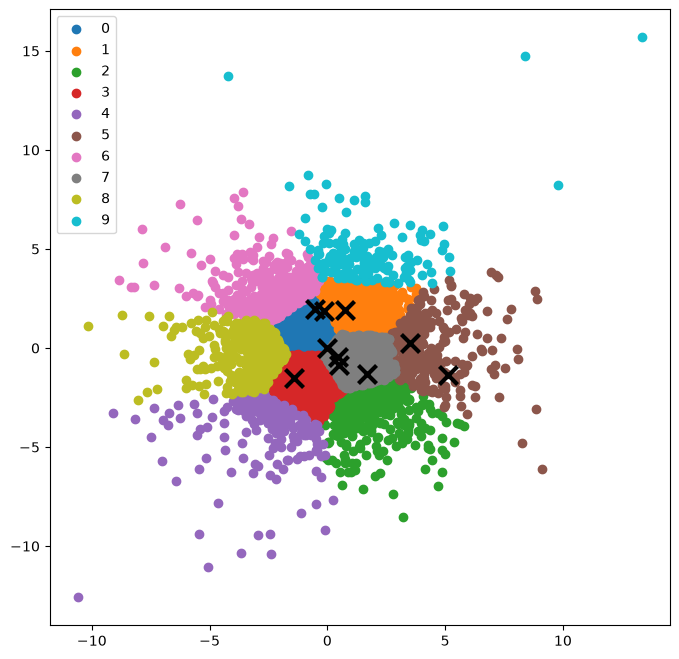

In [6]:
#Visualization
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

#Reducing the dataset
pca = PCA(2)
reduced_data = pca.fit_transform(scaled_data_clean)
kmeans_cluster.fit(scaled_data_clean)

#Calculating Centroids
centroids = pca.transform(kmeans_cluster.cluster_centers_)
labels= kmeans_cluster.fit_predict(reduced_data)
unique_labels = np.unique(labels)

#Plotting the clusters
plt.figure(figsize=(8,8))
for i in unique_labels:
    plt.scatter(reduced_data[labels  == i,0],
                reduced_data[labels  == i, 1],
                label = i)
plt.scatter(centroids[:,0], centroids[:,1], marker = 'x', s = 169, linewidths=3, color = 'k', zorder = 10)
plt.legend()
plt.show()


Each 'group' is grouped into clusters of similar characteristics <br>
 **Axes = PC1 and PC2**<br>
 <br>
 The 'X's represent the centroids - Average profile of groups inside that cluster
 <br>
 Principal Component Analysis - Transformed multiple variable dataset into 2 variables, good for visualization


In [7]:
data_with_clusters = data.copy()
data_with_clusters["Cluster"] = labels

cluster_summary = data_with_clusters.groupby("Cluster").mean(numeric_only=True)
print(cluster_summary)

           groupid  StartPigsInterval  TotalPigsIn  TotalPigsInWeight  \
Cluster                                                                 
0        50.597222          51.292824  2797.293981       49623.810996   
1        49.014151          50.309748  2743.339623       49888.881252   
2        48.877863          50.165394  2758.524173       50351.010461   
3        47.594164          50.515915  2791.988064       49274.441686   
4        46.172775          51.366492  2841.319372       49860.205823   
5        52.722603          51.684932  2851.335616       49447.518196   
6        49.957105          50.997319  2738.048257       51563.143997   
7        50.028058          49.243547  2736.564534       50697.228683   
8        47.770089          46.857143  2776.263393       48330.468899   
9        54.905063          48.265823  2655.613924       50996.830818   

         TotalPigsProduced  TotalStdPigs  TotalSubStdPigs  TotalLossQty  \
Cluster                                         

In [8]:
#Group Efficiency = TotalPigsProduced / TotalPigsIn
cluster_summary['Efficiency'] = (
    cluster_summary['TotalPigsProduced'] / cluster_summary['TotalPigsIn']
)

#Combine production and efficiency into a score
cluster_summary['Score'] = (
    cluster_summary['TotalPigsProduced'] * 0.6 +
    cluster_summary['Efficiency'] *0.4
)

#Rank Clusters
cluster_summary = cluster_summary.sort_values(by = "Score", ascending=False)

print(cluster_summary[['TotalPigsProduced', 'Efficiency', 'Score']])
#Assign Rankings
cluster_summary['Rank'] = range(1, len(cluster_summary) + 1)
print(cluster_summary[['Score', 'Rank']])
#Map rankings back to each individual group
cluster_rank_map = cluster_summary['Rank'].to_dict()
data_with_clusters['ClusterRank'] = data_with_clusters['Cluster'].map(cluster_rank_map)

         TotalPigsProduced  Efficiency         Score
Cluster                                             
4             52045.747481   18.317458  31234.775471
1             51140.582421   18.641725  30691.806143
5             50958.636263   17.871848  30582.330497
2             50877.826865   18.443858  30534.073662
3             50740.357959   18.173558  30451.484199
0             50571.952891   18.078884  30350.403288
7             50519.649446   18.460975  30319.174057
6             50060.503205   18.283280  30043.615235
8             49839.217540   17.951905  29910.711286
9             48912.471566   18.418518  29354.850347
                Score  Rank
Cluster                    
4        31234.775471     1
1        30691.806143     2
5        30582.330497     3
2        30534.073662     4
3        30451.484199     5
0        30350.403288     6
7        30319.174057     7
6        30043.615235     8
8        29910.711286     9
9        29354.850347    10


In [9]:
best_groups = data_with_clusters.sort_values(by = 'ClusterRank').head(10)
worst_groups = data_with_clusters.sort_values(by = 'ClusterRank', ascending=False).head(10)

print(best_groups)
print(worst_groups)
#Sorted in terms of efficiency


     CompanyId               ProducerName SiteName  groupid Groupname  \
4985     C1165                  Ayers Ltd   Site_4       36      Beta   
4971     C1149              Elliott Group  Site_77       97     Alpha   
1534     C1034                 Martin PLC  Site_88       55     Alpha   
4989     C1037                Mendoza LLC  Site_75       69      Beta   
3137     C1020            Jacobson-Glover  Site_84       57     Alpha   
4093     C1017  Perez, Gonzales and Carey  Site_32       53     Gamma   
76       C1105      Pope, Valdez and Hall  Site_85       39     Alpha   
1118     C1149              Cochran-Jones  Site_67       79     Gamma   
3836     C1122                 Howard Ltd   Site_4       14      Beta   
1137     C1088                  Munoz LLC   Site_9        6     Alpha   

     CombinedGroupName GroupType BusinessUnitName  StartPigsInterval  \
4985           Gamma-3     Type2            North                  1   
4971           Alpha-1     Type1            South   